In [141]:
from pathlib import Path
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss, ccf

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

%matplotlib inline

warnings.filterwarnings("ignore")

DATA_DIR = Path("../data")

for path in DATA_DIR.rglob("*"):
    if path.is_file():
        print(path)

../data/weather_features.csv
../data/df_final.csv
../data/energy_dataset.csv
../data/results_df.csv


In [142]:
df_results = pd.read_csv(
    DATA_DIR / "results_df.csv",
    index_col="time",
    parse_dates=["time"]
)

In [143]:
df_results.head()


,forecast_price,actual_price
time,,
2018-07-18 23:00:00+00:00,64.350500,67.08
2018-07-19 00:00:00+00:00,64.309010,65.19
2018-07-19 01:00:00+00:00,65.384930,62.87
2018-07-19 02:00:00+00:00,60.912740,63.02
2018-07-19 03:00:00+00:00,63.610653,64.50


In [144]:
# define a function that plots a time-series
def plot_series(df=None, column=None, series=pd.Series([]), label=None, ylabel=None,
                title=None, start=0, end=None):
    """
    Plots a certain time series which has either been loaded in the dataframe,
    or it is a custom pandas series created by the user. The user can also define 
    the 'df' and the 'column' or the 'series' and additionally, can also define the
    'label', the ylabel, the 'title', the 'start' and the 'end' of the plot.
    """
    sns.set_theme()
    fig, ax = plt.subplots(figsize=(30, 12))
    ax.set_xlabel('Time', fontsize=16)
    if column:
        ax.plot(df[column][start:end], label=label)
        ax.set_ylabel(ylabel, fontsize=16)
    if series.any():
        ax.plot(series, label=label)
        ax.set_ylabel(ylabel, fontsize=16)
    if label:
        ax.legend(fontsize=16)
    if title:
        ax.set_title(title, fontsize=24)
    ax.grid(True)
    return ax

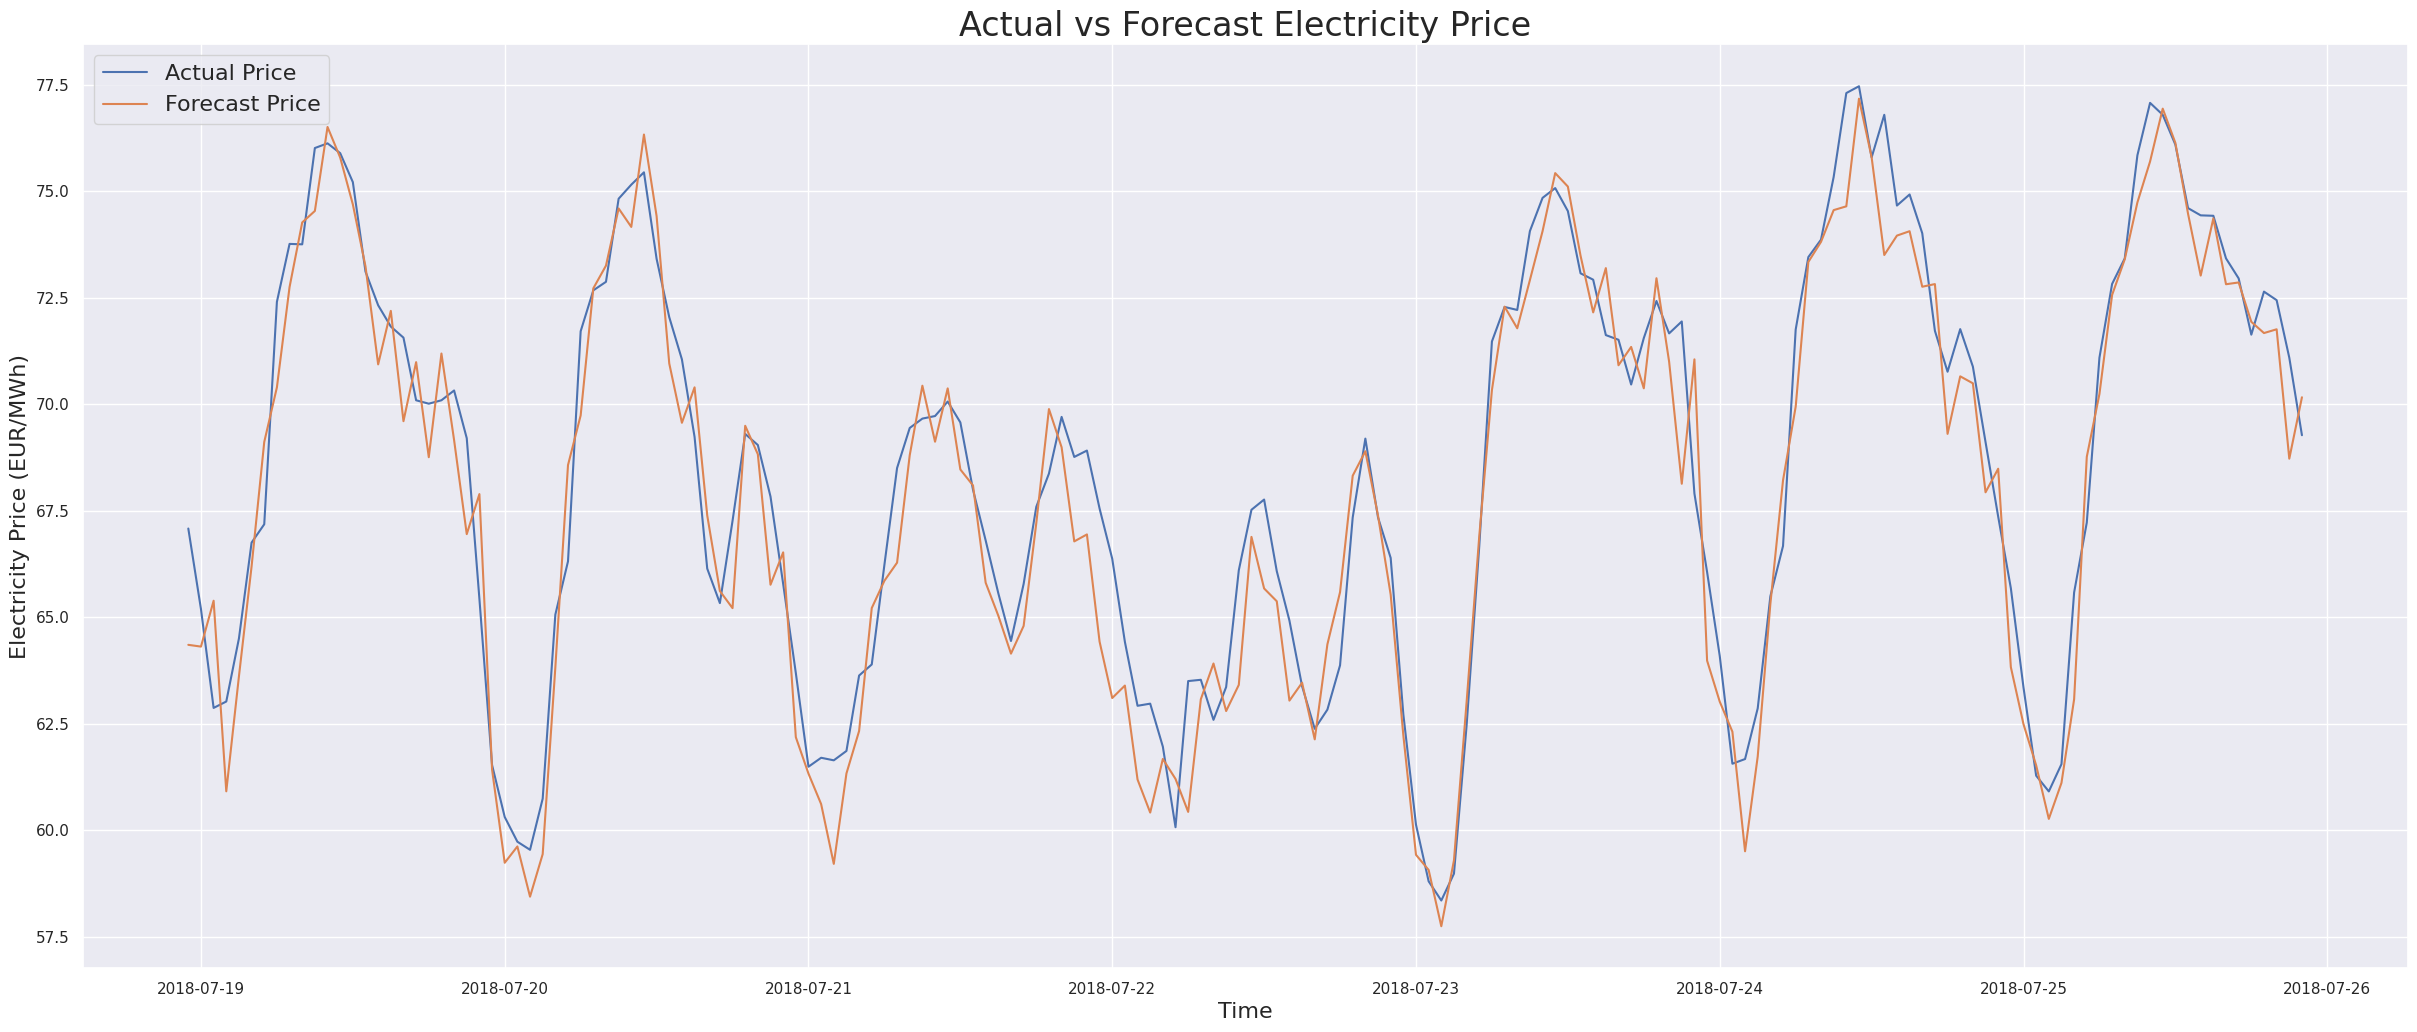

In [145]:
ax = plot_series(
    df=df_results,
    column='actual_price',
    label='Actual Price',
    ylabel='Electricity Price (EUR/MWh)',
    title='Actual vs Forecast Electricity Price',
    start=0,
    end=168
)

ax.plot(
    df_results['forecast_price'].iloc[0:168],
    label='Forecast Price'
)

ax.legend(fontsize=16)

plt.show()

In [146]:
print(df_results.isna().sum())
print(df_results.index.to_series().diff().value_counts().head())

forecast_price    0
actual_price      0
dtype: int64
time
0 days 01:00:00    3983
Name: count, dtype: int64


In [147]:
# Battery Parameters

from dataclasses import dataclass

@dataclass
class BatteryConfig:
    # Physical Battery
    power_mw: float = 10.0
    capacity_mwh: float = 30.0

    min_soc: float = 0.05
    max_soc: float = 0.95
    initial_soc: float = 0.50

    # Efficiency
    charge_efficiency: float = 0.98
    discharge_efficiency: float = 0.98

    # Costs per MWh sold
    degredation_cost_per_mwh: float = 0.0
    fees_per_mwh: float = 0.0

    # Used to decide whether to trade
    risk_buffer_per_mwh: float = 0.0

    # Constraint from the paper
    maximum_recharge_delay_hours: int = 12


In [148]:
battery = BatteryConfig()

round_trip_efficiency = (
    battery.charge_efficiency
    * battery.discharge_efficiency
)

print(round_trip_efficiency)

0.9603999999999999


In [149]:
# Final data checks
df_results = df_results.reset_index()

df_results["time"] = pd.to_datetime(df_results["time"])

df_results = df_results.sort_values("time").reset_index(drop=True)

df_results["date"] = df_results["time"].dt.date

In [150]:
df_results.head()


,time,forecast_price,actual_price,date
0,2018-07-18 23:00:00+00:00,64.350500,67.08,2018-07-18
1,2018-07-19 00:00:00+00:00,64.309010,65.19,2018-07-19
2,2018-07-19 01:00:00+00:00,65.384930,62.87,2018-07-19
3,2018-07-19 02:00:00+00:00,60.912740,63.02,2018-07-19
4,2018-07-19 03:00:00+00:00,63.610653,64.50,2018-07-19


In [151]:
df_results.columns

Index(['time', 'forecast_price', 'actual_price', 'date'], dtype='str')

In [152]:
# Forecast Margin
def calculate_forecast_margin(
        forecast_sell_price: float,
        forecast_buy_price: float,
        battery: BatteryConfig,
) -> float:
    
    eta_rt = (
        battery.charge_efficiency
        * battery.discharge_efficiency
    )

    forecast_margin = (
        forecast_sell_price
        - forecast_buy_price / eta_rt
        - battery.degredation_cost_per_mwh
        - battery.fees_per_mwh
        - battery.risk_buffer_per_mwh
    )

    return forecast_margin

In [153]:
# Realised margin
def calculate_realised_margin(
        actual_sell_price: float,
        actual_buy_price: float,
        battery: BatteryConfig, 
) -> float:
    
    eta_rt = (
        battery.charge_efficiency
        * battery.discharge_efficiency
    )

    realised_margin = (
        actual_sell_price
        - actual_buy_price / eta_rt
        - battery.degredation_cost_per_mwh
        - battery.fees_per_mwh
    )

    return realised_margin

In [154]:
# Calculate available discharge energy
def calculate_maximum_discharge_mwh(
        current_soc: float,
        battery: BatteryConfig,
        interval_hours: float = 1.0,
) -> float:
    
    stored_energy_mwh = (
        current_soc
        * battery.capacity_mwh
    )

    minimum_energy_mwh = (
        battery.min_soc
        * battery.capacity_mwh
    )

    available_internal_energy_mwh = max(
        0.0,
        stored_energy_mwh - minimum_energy_mwh,
    )

    maximum_due_to_soc = (
        available_internal_energy_mwh
        * battery.discharge_efficiency
    )

    maximum_due_to_power = (
        battery.power_mw
        * interval_hours
    )

    return min(
        maximum_due_to_soc,
        maximum_due_to_power,
    )

In [155]:
# Calculate required recharge energy
def calculate_required_recharge_mwh(
        energy_sold_mwh: float,
        battery: BatteryConfig,
) -> float:
    
    eta_rt = (
        battery.charge_efficiency
        * battery.discharge_efficiency
    )

    return energy_sold_mwh / eta_rt

In [156]:
# Ensure the recharge fits within one hour
def calculate_maximum_sell_for_recharge(
        battery: BatteryConfig,
        interval_hours: float = 1.0,
) -> float:
    
    eta_rt = (
        battery.charge_efficiency
        * battery.discharge_efficiency
    )

    maximum_grid_purchase_mwh = (
        battery.power_mw
        * interval_hours
    )

    maximum_sell_energy_mwh = (
        maximum_grid_purchase_mwh
        * eta_rt
    )

    return maximum_sell_energy_mwh


In [157]:
# Generate all candidate trades
def generate_daily_trade_candidates(
        daily_data: pd.DataFrame,
        battery: BatteryConfig,
        interval_hours: float = 1.0,
) -> pd.DataFrame:
    """ 
    Generate all profitable discharge-recharge pairs for one day.
    
    """

    day = (
        daily_data
        .sort_values("time")
        .reset_index(drop=True)
    )

    candidates = []

    eta_rt = (
        battery.charge_efficiency
        * battery.discharge_efficiency
    )

    for discharge_index in range(len(day)):

        for delay in range(
            1,
            battery.maximum_recharge_delay_hours + 1,
        ):
            recharge_index = discharge_index + delay

            if recharge_index >= len(day):
                continue

            discharge_row = day.iloc[discharge_index]
            recharge_row = day.iloc[recharge_index]

            forecast_margin = calculate_forecast_margin(
                forecast_sell_price = discharge_row['forecast_price'],
                forecast_buy_price = recharge_row['forecast_price'],
                battery=battery,
            )

            if forecast_margin <= 0:
                continue

            candidates.append({
                'date': discharge_row['time'].date(),

                'discharge_index': discharge_index,
                'recharge_index': recharge_index,

                'discharge_time': discharge_row['time'],
                'recharge_time': recharge_row['time'],

                'forecast_sell_price': discharge_row['forecast_price'],
                'forecast_buy_price': recharge_row['forecast_price'],

                'actual_sell_price': discharge_row['actual_price'],
                'actual_buy_price': recharge_row['actual_price'],

                'forecast_margin_per_mwh': forecast_margin,

            })
        
    if not candidates:
        return pd.DataFrame()
    
    candidates = pd.DataFrame(candidates)

    candidates = candidates.sort_values(
        'forecast_margin_per_mwh', 
        ascending=False,
    ).reset_index(drop=True)

    return candidates

In [158]:
def ranked_trades_chronologically(
        daily_data: pd.DataFrame,
        battery: BatteryConfig,
        interval_hours: float = 1.0,
) -> pd.DataFrame:
    
    day = (
        daily_data
        .sort_values('time')
        .reset_index(drop=True)   
    )

    candidates = generate_daily_trade_candidates(
        daily_data=day,
        battery=battery,
        interval_hours=interval_hours
    )

    if candidates.empty:
        return pd.DataFrame()
    
    selected_trades = []
    used_hours = set()

    # First select the best non-overlapping trades
    for _, trade in candidates.iterrows():

        discharge_index = int(trade['discharge_index'])
        recharge_index = int(trade['recharge_index'])

        occupied_hours = set(
            range(discharge_index, recharge_index + 1)
        )

        if used_hours.intersection(occupied_hours):
            continue

        selected_trades.append(trade.to_dict())

        used_hours.update(occupied_hours)

        

    
    if not selected_trades:
        return pd.DataFrame()
    
    selected_trades = pd.DataFrame(selected_trades)

    # Then execute in time order
    selected_trades = selected_trades.sort_values(
        'discharge_time'
    ).reset_index(drop=True)

    current_soc = battery.initial_soc
    executed_trades = []

    for _, trade in selected_trades.iterrows():

        max_discharge_from_soc = calculate_maximum_discharge_mwh(
            current_soc=current_soc,
            battery=battery,
            interval_hours=interval_hours,
        )

        max_sell_for_recharge = calculate_maximum_sell_for_recharge(
            battery=battery,
            interval_hours=interval_hours
        )

        energy_sold_mwh = min(
            max_discharge_from_soc,
            max_sell_for_recharge,
        )

        if energy_sold_mwh <= 0:
            continue

        energy_bought_mwh = calculate_required_recharge_mwh(
            energy_sold_mwh=energy_sold_mwh,
            battery=battery,
        )

        expected_profit = (
            trade['forecast_margin_per_mwh']
            * energy_sold_mwh
        )

        realised_margin = calculate_realised_margin(
            actual_sell_price=trade['actual_sell_price'],
            actual_buy_price=trade['actual_buy_price'],
            battery=battery,
        )

        realised_profit = realised_margin * energy_sold_mwh

        stored_energy_before = (
            current_soc
            * battery.capacity_mwh
        )

        internal_energy_removed = (
            energy_sold_mwh
            / battery.discharge_efficiency
        )

        internal_energy_added = (
            energy_bought_mwh
            * battery.charge_efficiency
        )

        stored_energy_after = (
            stored_energy_before
            - internal_energy_removed
            + internal_energy_added
        )

        current_soc = (
            stored_energy_after
            / battery.capacity_mwh
        )

        current_soc = min(
            max(current_soc, battery.min_soc),
            battery.max_soc,
        )

        executed_trades.append({
            **trade.to_dict(),

            'energy_sold_mwh': energy_sold_mwh,
            'energy_bought_mwh': energy_bought_mwh,

            'expected_profit': expected_profit,

            'realised_margin_per_mwh': realised_margin,
            'realised_profit': realised_profit,

            'soc_after_trade': current_soc,

            'profitable_trade': realised_profit > 0,  
        })

    if not executed_trades:
        return pd.DataFrame()
    
    return pd.DataFrame(executed_trades)
    
        
    

In [159]:
# Backtest Function
def backtest_ranked_strategy(
    df: pd.DataFrame,
    battery: BatteryConfig,
    interval_hours: float = 1.0,
) -> pd.DataFrame:

    data = df.copy()

    data["time"] = pd.to_datetime(data["time"])
    data = data.sort_values("time").reset_index(drop=True)
    data["date"] = data["time"].dt.date

    all_trades = []

    for date, daily_data in data.groupby("date"):

        daily_trades = ranked_trades_chronologically(
            daily_data=daily_data,
            battery=battery,
            interval_hours=interval_hours,
        )

        if not daily_trades.empty:
            all_trades.append(daily_trades)

    if not all_trades:
        return pd.DataFrame()

    return pd.concat(all_trades, ignore_index=True)

In [160]:
results_test = backtest_ranked_strategy(
    df=df_results,
    battery=battery,
    interval_hours=1.0,
)

print(results_test.shape)
display(results_test.head(30))

(403, 17)


,date,discharge_index,recharge_index,discharge_time,recharge_time,forecast_sell_price,forecast_buy_price,actual_sell_price,actual_buy_price,forecast_margin_per_mwh,energy_sold_mwh,energy_bought_mwh,expected_profit,realised_margin_per_mwh,realised_profit,soc_after_trade,profitable_trade
0,2018-07-19,1,2,2018-07-19 01:00:00+00:00,2018-07-19 02:00:00+00:00,65.384930,60.912740,62.87,63.02,1.960586,9.604,10.0,18.829468,-2.748492,-26.39652,0.5,False
1,2018-07-19,11,23,2018-07-19 11:00:00+00:00,2018-07-19 23:00:00+00:00,75.787170,61.424210,75.89,61.53,11.830267,9.604,10.0,113.617881,11.822945,113.54756,0.5,True
2,2018-07-20,11,23,2018-07-20 11:00:00+00:00,2018-07-20 23:00:00+00:00,76.326490,62.183716,75.44,63.69,11.578764,9.604,10.0,111.202450,9.123882,87.62576,0.5,True
3,2018-07-21,9,16,2018-07-21 09:00:00+00:00,2018-07-21 16:00:00+00:00,70.432260,64.143710,69.66,64.44,3.643724,9.604,10.0,34.994325,2.562957,24.61464,0.5,True
4,2018-07-21,19,23,2018-07-21 19:00:00+00:00,2018-07-21 23:00:00+00:00,69.884040,64.426025,68.37,67.55,2.801548,9.604,10.0,26.906070,-1.965277,-18.87452,0.5,False
5,2018-07-22,1,3,2018-07-22 01:00:00+00:00,2018-07-22 03:00:00+00:00,63.394300,60.413857,64.42,62.97,0.489409,9.604,10.0,4.700287,-1.146431,-11.01032,0.5,False
6,2018-07-22,11,16,2018-07-22 11:00:00+00:00,2018-07-22 16:00:00+00:00,66.883510,62.131610,67.52,62.38,2.190039,9.604,10.0,21.033130,2.567897,24.66208,0.5,True
7,2018-07-22,20,23,2018-07-22 20:00:00+00:00,2018-07-22 23:00:00+00:00,68.893330,62.228806,69.19,62.72,4.098655,9.604,10.0,39.363481,3.883878,37.30076,0.5,True
8,2018-07-23,11,23,2018-07-23 11:00:00+00:00,2018-07-23 23:00:00+00:00,75.421530,63.979950,75.07,66.06,8.803506,9.604,10.0,84.548874,6.286160,60.37228,0.5,True
9,2018-07-24,0,2,2018-07-24 00:00:00+00:00,2018-07-24 02:00:00+00:00,63.016926,59.505417,64.09,61.67,1.057933,9.604,10.0,10.160387,-0.122828,-1.17964,0.5,False


In [161]:
results_test['realised_profit'].sum()

np.float64(19419.27963999997)

In [162]:
results = backtest_ranked_strategy(
    df=df_results,
    battery=battery,
    interval_hours=1.0,
)

print(type(results))
print(results.shape)
print(results.empty)

display(results.head())

<class 'pandas.DataFrame'>
(403, 17)
False


,date,discharge_index,recharge_index,discharge_time,recharge_time,forecast_sell_price,forecast_buy_price,actual_sell_price,actual_buy_price,forecast_margin_per_mwh,energy_sold_mwh,energy_bought_mwh,expected_profit,realised_margin_per_mwh,realised_profit,soc_after_trade,profitable_trade
0,2018-07-19,1,2,2018-07-19 01:00:00+00:00,2018-07-19 02:00:00+00:00,65.38493,60.912740,62.87,63.02,1.960586,9.604,10.0,18.829468,-2.748492,-26.39652,0.5,False
1,2018-07-19,11,23,2018-07-19 11:00:00+00:00,2018-07-19 23:00:00+00:00,75.78717,61.424210,75.89,61.53,11.830267,9.604,10.0,113.617881,11.822945,113.54756,0.5,True
2,2018-07-20,11,23,2018-07-20 11:00:00+00:00,2018-07-20 23:00:00+00:00,76.32649,62.183716,75.44,63.69,11.578764,9.604,10.0,111.202450,9.123882,87.62576,0.5,True
3,2018-07-21,9,16,2018-07-21 09:00:00+00:00,2018-07-21 16:00:00+00:00,70.43226,64.143710,69.66,64.44,3.643724,9.604,10.0,34.994325,2.562957,24.61464,0.5,True
4,2018-07-21,19,23,2018-07-21 19:00:00+00:00,2018-07-21 23:00:00+00:00,69.88404,64.426025,68.37,67.55,2.801548,9.604,10.0,26.906070,-1.965277,-18.87452,0.5,False


In [163]:
results = backtest_ranked_strategy(
    df=df_results,
    battery=battery,
    interval_hours=1.0,
)

results.head()

,date,discharge_index,recharge_index,discharge_time,recharge_time,forecast_sell_price,forecast_buy_price,actual_sell_price,actual_buy_price,forecast_margin_per_mwh,energy_sold_mwh,energy_bought_mwh,expected_profit,realised_margin_per_mwh,realised_profit,soc_after_trade,profitable_trade
0,2018-07-19,1,2,2018-07-19 01:00:00+00:00,2018-07-19 02:00:00+00:00,65.38493,60.912740,62.87,63.02,1.960586,9.604,10.0,18.829468,-2.748492,-26.39652,0.5,False
1,2018-07-19,11,23,2018-07-19 11:00:00+00:00,2018-07-19 23:00:00+00:00,75.78717,61.424210,75.89,61.53,11.830267,9.604,10.0,113.617881,11.822945,113.54756,0.5,True
2,2018-07-20,11,23,2018-07-20 11:00:00+00:00,2018-07-20 23:00:00+00:00,76.32649,62.183716,75.44,63.69,11.578764,9.604,10.0,111.202450,9.123882,87.62576,0.5,True
3,2018-07-21,9,16,2018-07-21 09:00:00+00:00,2018-07-21 16:00:00+00:00,70.43226,64.143710,69.66,64.44,3.643724,9.604,10.0,34.994325,2.562957,24.61464,0.5,True
4,2018-07-21,19,23,2018-07-21 19:00:00+00:00,2018-07-21 23:00:00+00:00,69.88404,64.426025,68.37,67.55,2.801548,9.604,10.0,26.906070,-1.965277,-18.87452,0.5,False
